In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_mnist  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_fashion = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_fashion  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader_mnist = DataLoader(train_mnist, batch_size=batch_size, shuffle=True)
test_loader_mnist = DataLoader(test_mnist, batch_size=batch_size, shuffle=False)

train_loader_fashion = DataLoader(train_fashion, batch_size=batch_size, shuffle=True)
test_loader_fashion = DataLoader(test_fashion, batch_size=batch_size, shuffle=False)

In [16]:
image, label = train_mnist[0]
print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


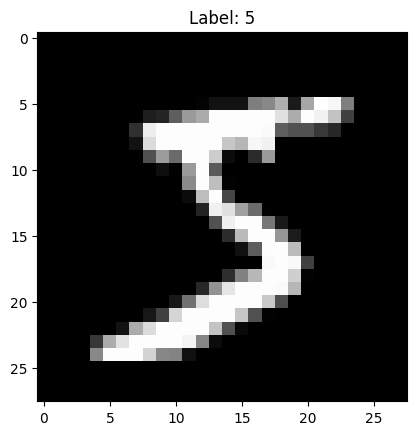

In [17]:
import matplotlib.pyplot as plt

img = image
img = img.squeeze()

plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [18]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2), # 14x14
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 7x7
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )

        self._to_linear = 32 * 7 * 7

        self.head_mnist = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._to_linear, 10)
        )

        self.head_fashion = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._to_linear, 10)
        )

    def forward(self, x, head='mnist'):
        x = self.features(x)
        if head == 'mnist':
            return self.head_mnist(x)
        elif head == 'fashion':
            return self.head_fashion(x)
        else:
            raise ValueError("Unknown head")

model = MyModel().to(device)
criterion = nn.CrossEntropyLoss()

In [19]:
history = {
    'stage1_mnist': {'loss': [], 'f1': []},
    'stage2_frozen': {'loss': [], 'f1': []},
    'stage3_fine': {'loss': [], 'f1_fashion': [], 'f1_mnist': []},
    'stage4_imm': {'loss': [], 'f1_fashion': [], 'f1_mnist': []},
    'stage5_rand': {'loss': [], 'f1': []}
}

best_fashion_f1 = 0.0
best_model_state = None

def train_one_epoch(model, loader, optimizer, head):
    model.train()

    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
    
        optimizer.zero_grad()
        outputs = model(images, head)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    return running_loss / len(loader)

def evaluate(model, loader, head):
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images, head)
    
            _, predicted = torch.max(outputs.data, 1)
    
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return f1_score(all_labels, all_preds, average='macro') * 100

def update_best_model(model, current_f1):
    global best_fashion_f1, best_model_state
    
    if current_f1 > best_fashion_f1:
        best_fashion_f1 = current_f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  >>> New best model saved (F1: {current_f1:.2f}%)")

Train MNIST

In [20]:
n_epoch = 5

print("MNIST Training")
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(n_epoch):
    loss = train_one_epoch(model, train_loader_mnist, optimizer, 'mnist')
    f1 = evaluate(model, test_loader_mnist, 'mnist')
    history['stage1_mnist']['loss'].append(loss)
    history['stage1_mnist']['f1'].append(f1)
    print(f"Epoch {epoch+1}: Loss {loss:.4f}, MNIST F1 {f1:.2f}%")

# Сохраняем состояние после обучения первой головы
weights_after_mnist = copy.deepcopy(model.state_dict())

MNIST Training
Epoch 1: Loss 0.2455, MNIST F1 97.38%
Epoch 2: Loss 0.0672, MNIST F1 98.33%
Epoch 3: Loss 0.0460, MNIST F1 98.70%
Epoch 4: Loss 0.0352, MNIST F1 98.69%
Epoch 5: Loss 0.0285, MNIST F1 98.65%


Frozen Backbone, Train Fashion

In [21]:
print("FashionMNIST (Frozen Backbone)")
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

for epoch in range(n_epoch):
    loss = train_one_epoch(model, train_loader_fashion, optimizer, 'fashion')
    f1 = evaluate(model, test_loader_fashion, 'fashion')
    
    history['stage2_frozen']['loss'].append(loss)
    history['stage2_frozen']['f1'].append(f1)
    
    update_best_model(model, f1)
    print(f"Epoch {epoch+1}: Loss {loss:.4f}, Fashion F1 {f1:.2f}%")

FashionMNIST (Frozen Backbone)
  >>> New best model saved (F1: 85.97%)
Epoch 1: Loss 0.4709, Fashion F1 85.97%
  >>> New best model saved (F1: 87.15%)
Epoch 2: Loss 0.3508, Fashion F1 87.15%
  >>> New best model saved (F1: 87.52%)
Epoch 3: Loss 0.3202, Fashion F1 87.52%
  >>> New best model saved (F1: 87.66%)
Epoch 4: Loss 0.3025, Fashion F1 87.66%
  >>> New best model saved (F1: 87.70%)
Epoch 5: Loss 0.2904, Fashion F1 87.70%


Unfreeze & Fine-tune

In [22]:
print("Fine-tuning (Unfrozen)")
for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(n_epoch):
    loss = train_one_epoch(model, train_loader_fashion, optimizer, 'fashion')
    f1_f = evaluate(model, test_loader_fashion, 'fashion')
    f1_m = evaluate(model, test_loader_mnist, 'mnist')
    
    history['stage3_fine']['loss'].append(loss)
    history['stage3_fine']['f1_fashion'].append(f1_f)
    history['stage3_fine']['f1_mnist'].append(f1_m)
    
    update_best_model(model, f1_f)
    print(f"Epoch {epoch+1}: Loss {loss:.4f}, Fash F1 {f1_f:.2f}%, MNIST F1 {f1_m:.2f}%")

Fine-tuning (Unfrozen)
  >>> New best model saved (F1: 88.39%)
Epoch 1: Loss 0.2618, Fash F1 88.39%, MNIST F1 98.60%
  >>> New best model saved (F1: 88.64%)
Epoch 2: Loss 0.2516, Fash F1 88.64%, MNIST F1 98.68%
  >>> New best model saved (F1: 88.78%)
Epoch 3: Loss 0.2459, Fash F1 88.78%, MNIST F1 98.68%
Epoch 4: Loss 0.2415, Fash F1 88.60%, MNIST F1 98.64%
Epoch 5: Loss 0.2375, Fash F1 88.78%, MNIST F1 98.70%


Reload & Immediate Unfreeze

In [23]:
print("Reload Weights & Train Unfrozen")
model.load_state_dict(weights_after_mnist)
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(n_epoch):
    loss = train_one_epoch(model, train_loader_fashion, optimizer, 'fashion')
    f1_f = evaluate(model, test_loader_fashion, 'fashion')
    f1_m = evaluate(model, test_loader_mnist, 'mnist')
    
    history['stage4_imm']['loss'].append(loss)
    history['stage4_imm']['f1_fashion'].append(f1_f)
    history['stage4_imm']['f1_mnist'].append(f1_m)
    
    update_best_model(model, f1_f)
    print(f"Epoch {epoch+1}: Loss {loss:.4f}, Fash F1 {f1_f:.2f}%")

Reload Weights & Train Unfrozen
Epoch 1: Loss 0.4050, Fash F1 87.76%
Epoch 2: Loss 0.2944, Fash F1 88.67%
  >>> New best model saved (F1: 89.21%)
Epoch 3: Loss 0.2634, Fash F1 89.21%
  >>> New best model saved (F1: 89.78%)
Epoch 4: Loss 0.2430, Fash F1 89.78%
Epoch 5: Loss 0.2275, Fash F1 89.42%


Random Init + Partial Freeze

In [ ]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None: nn.init.zeros_(m.bias)

model.apply(init_weights)

for param in model.features[0].parameters():
    param.requires_grad = False
    
for param in model.features[3:].parameters():
    param.requires_grad = True
    
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

for epoch in range(n_epoch):
    loss = train_one_epoch(model, train_loader_fashion, optimizer, 'fashion')
    f1 = evaluate(model, test_loader_fashion, 'fashion')

    history['stage5_rand']['loss'].append(loss)
    history['stage5_rand']['f1'].append(f1)

    update_best_model(model, f1)
    print(f"Epoch {epoch+1}: Loss {loss:.4f}, Fash F1 {f1:.2f}%")

Epoch 1: Loss 0.5234, Fash F1 85.55%
Epoch 2: Loss 0.3565, Fash F1 87.25%
Epoch 3: Loss 0.3160, Fash F1 88.03%
Epoch 4: Loss 0.2914, Fash F1 88.43%
Epoch 5: Loss 0.2736, Fash F1 89.34%


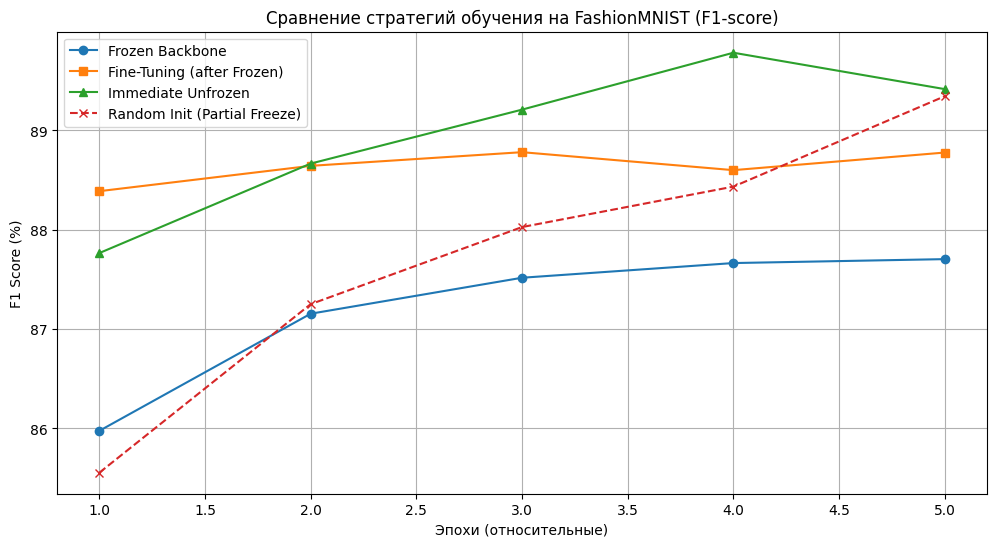

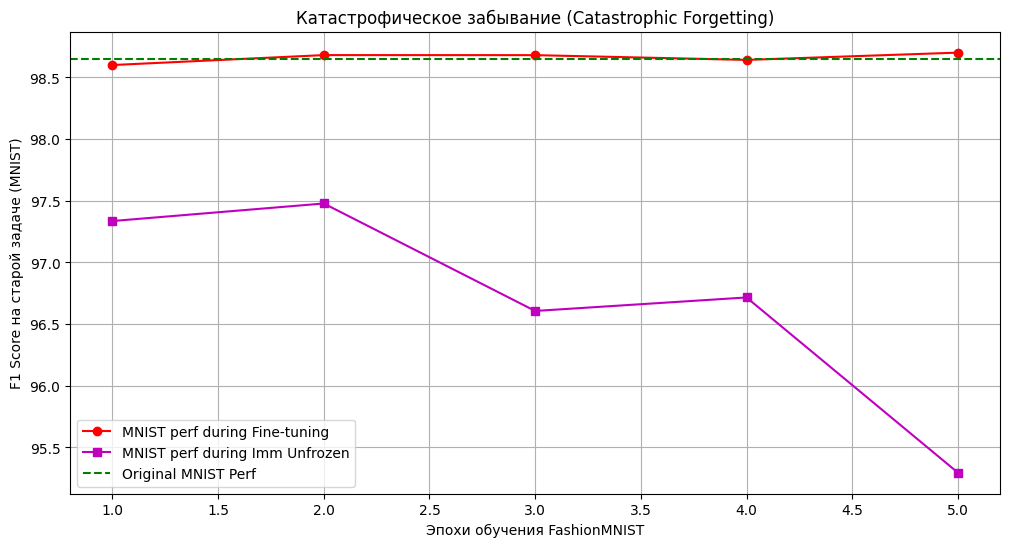

In [25]:
plt.figure(figsize=(12, 6))

epochs = range(1, n_epoch + 1)

# Сравниваем сходимость на FashionMNIST для разных стратегий
plt.plot(epochs, history['stage2_frozen']['f1'], 'o-', label='Frozen Backbone')
plt.plot(epochs, history['stage3_fine']['f1_fashion'], 's-', label='Fine-Tuning (after Frozen)')
plt.plot(epochs, history['stage4_imm']['f1_fashion'], '^-', label='Immediate Unfrozen')
plt.plot(epochs, history['stage5_rand']['f1'], 'x--', label='Random Init (Partial Freeze)')

plt.title('Сравнение стратегий обучения на FashionMNIST (F1-score)')
plt.xlabel('Эпохи (относительные)')
plt.ylabel('F1 Score (%)')
plt.legend()
plt.grid(True)
plt.show()

# Отдельно график "Забывания" MNIST
plt.figure(figsize=(12, 6))
plt.plot(epochs, history['stage3_fine']['f1_mnist'], 'r-o', label='MNIST perf during Fine-tuning')
plt.plot(epochs, history['stage4_imm']['f1_mnist'], 'm-s', label='MNIST perf during Imm Unfrozen')
plt.axhline(y=history['stage1_mnist']['f1'][-1], color='g', linestyle='--', label='Original MNIST Perf')
plt.title('Катастрофическое забывание (Catastrophic Forgetting)')
plt.xlabel('Эпохи обучения FashionMNIST')
plt.ylabel('F1 Score на старой задаче (MNIST)')
plt.legend()
plt.grid(True)
plt.show()

Loading best model with F1: 89.78%


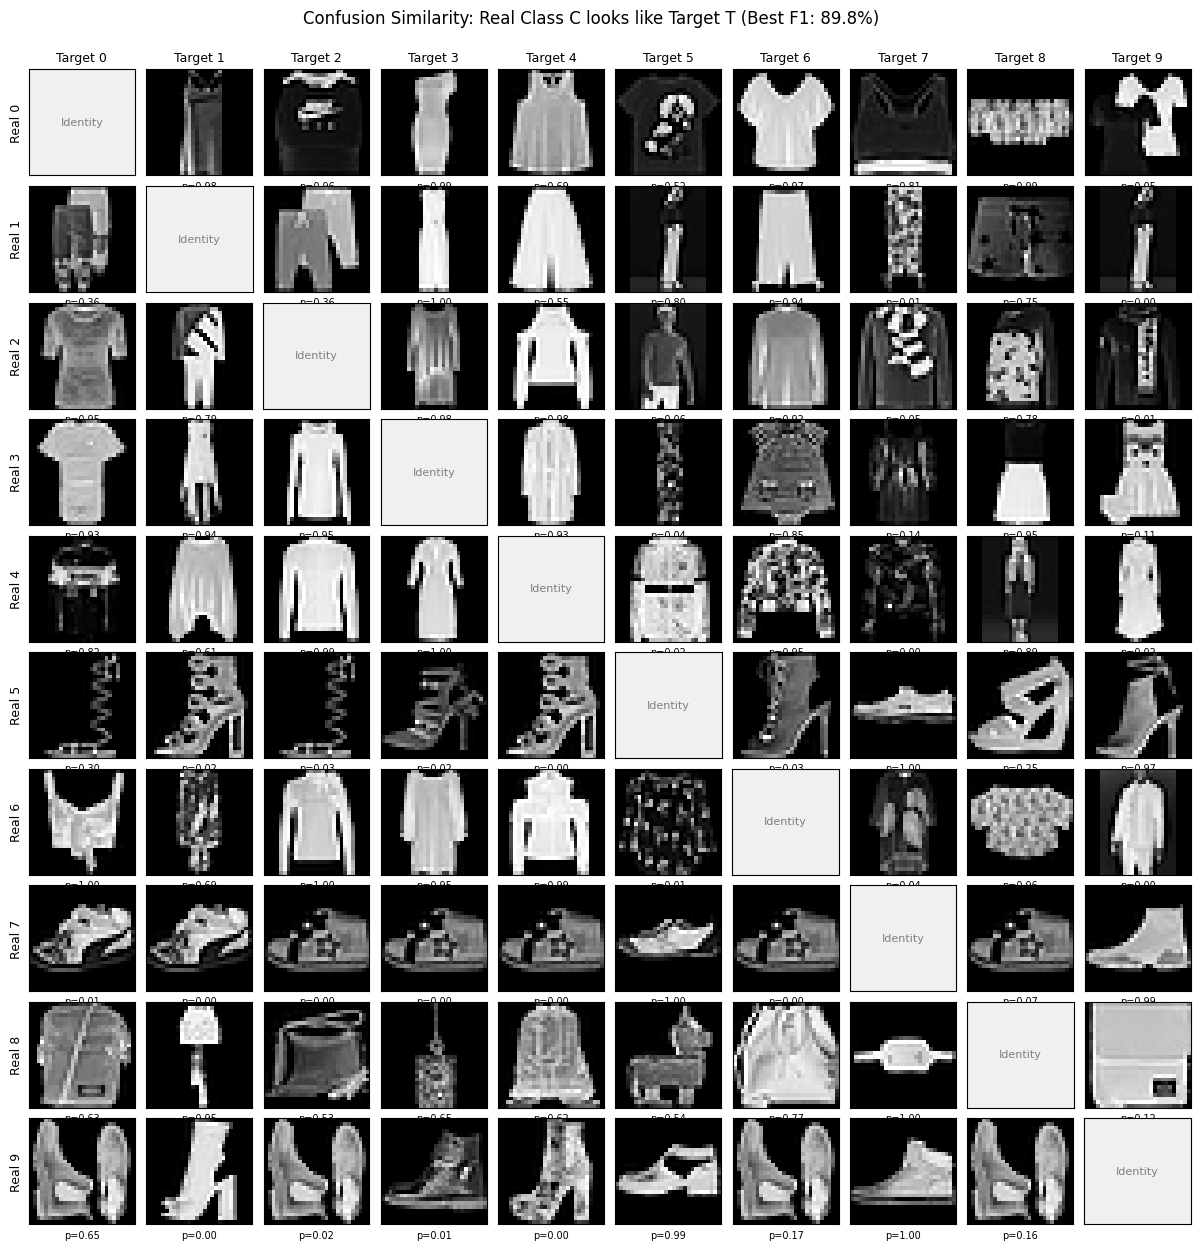

In [26]:
print(f"Loading best model with F1: {best_fashion_f1:.2f}%")
model.load_state_dict(best_model_state)

def get_similarity_matrix(model, dataset):
    model.eval()
    sim_matrix = [[(0.0, None) for _ in range(10)] for _ in range(10)]
    
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images, head='fashion')
            probs_batch = F.softmax(outputs, dim=1)
            
            for k in range(images.size(0)):
                prob = probs_batch[k]
                c = labels[k].item()
                img = images[k].cpu()
                
                for t_idx in range(10):
                    if c == t_idx: continue
                    current_p = prob[t_idx].item()
                    
                    if current_p > sim_matrix[c][t_idx][0]:
                        sim_matrix[c][t_idx] = (current_p, img)

    return sim_matrix

matrix = get_similarity_matrix(model, test_fashion)

fig, axes = plt.subplots(10, 10, figsize=(15, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for c in range(10):
    for t_cls in range(10):
        ax = axes[c, t_cls]
        ax.set_xticks([])
        ax.set_yticks([])
        
        if c == t_cls:
            ax.text(0.5, 0.5, "Identity", ha='center', va='center', fontsize=8, color='gray')
            ax.set_facecolor('#f0f0f0')
        else:
            prob, img = matrix[c][t_cls]
            if img is not None:
                img_show = img.squeeze() * 0.5 + 0.5
                ax.imshow(img_show, cmap='gray')
                ax.set_xlabel(f"p={prob:.2f}", fontsize=7)
            else:
                ax.text(0.5, 0.5, "-", ha='center')

        if c == 0: ax.set_title(f"Target {t_cls}", fontsize=9)
        if t_cls == 0: ax.set_ylabel(f"Real {c}", fontsize=9)

plt.suptitle(f"Confusion Similarity: Real Class C looks like Target T (Best F1: {best_fashion_f1:.1f}%)", y=0.92)
plt.show()